<a href="https://colab.research.google.com/github/PradipBanik/Build_2026/blob/main/Andrew_Karaoathy_summary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [164]:
import numpy as np

class nodes:
  def __init__(self, data, prev=(), op='', label=''):
    self._data = data
    self._prev = set(prev)
    self._op = op
    self._label = label
    self._grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"{self._label}"

  def __add__(self, other):
    other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    add_out = nodes(self._data + other._data, (self, other), '+')
    def _backward():
      self._grad += 1.0 * add_out._grad
      other._grad += 1.0 * add_out._grad
    add_out._backward = _backward
    return add_out

  def __radd__(self, other):
    return self + other

  def __sub__(self, other):
    other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    out =  nodes(self._data-other._data, (self, other), '-')
    def _backward():
      self._grad += 1.0 * out._grad
      other._grad += -1.0 * out._grad
    out._backward = _backward
    return out

  def __rsub__(self,other):
      return nodes(other, label=f"{other}")-self

  def __neg__(self):
      return self * -1

  def __mul__(self, other):
    other = other if isinstance(other, nodes) else nodes(other, label=f"{other}")
    out = nodes(self._data * other._data, (self, other), '*')
    def _backward():
      self._grad += other._data * out._grad
      other._grad += self._data * out._grad
    out._backward = _backward
    return out

  def __rmul__(self, other):
    return self * other

  def __pow__(self, other):
    assert isinstance(other, (int,float)), "only float and int are supported"
    out = nodes(self._data ** other, (self,), f"**{other}")
    def _backward():
      self._grad += other * (self._data ** (other  - 1)) * out._grad
    out._backward = _backward
    return out

  def __truediv__(self, other):
    return self * (other**-1)

  def __rtruediv__(self, other):
    return nodes(other, label=f"{other}") / self

  def exp(self):
    out = nodes(np.exp(self._data), (self,), 'e')
    def _backward():
      self._grad += out._data * out._grad
    out._backward = _backward
    return out

  def tanh(self):
    e2x = (self * 2).exp()
    e2x._op = 'e^2x'

    out = (e2x - 1) *( (e2x + 1)**-1)
    out._op = 'tanh'
    return out

  def _sin(self):
    v = self._data
    out_sin = nodes(np.sin(v), (self,), 'sin')

    def _backward():
      self._grad += np.cos(v) * out_sin._grad
    out_sin._backward = _backward
    return out_sin

  def _cos(self):
    v = self._data
    out_cos = nodes(np.cos(v), (self,), 'cos')
    def _backeard():
      self._grad += -np.sin(v) * out_cos._grad
    out_cos._backward = _backeard
    return out_cos

  def backward(self):
    topo=[]
    visited=[]
    def build_topo(v):
      if v not in visited:
        visited.append(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    self._grad = 1.0
    for node in reversed(topo):
      node._backward()

w1 = nodes(2, label='w1')
w2 = nodes(5, label='w2')
c = w2+w1; c._label='c'
d = c*w2; d._label='d'
s = 5 - d; s._label='s'
p = s ** 4; p._label = 'p'
div = p/s; div._label = 'div'
tanh = div.tanh(); tanh._label = 'tanh'
tanh.backward()

print(f"tanh result: {tanh._data}")
print(f"w1 gradient: {w1._grad}")

tanh result: -1.0
w1 gradient: 0.0


### Mathematical Breakdown of `(self * 2).exp()`

1.  **`self * 2`**: This triggers `__mul__`. It creates a new node where the data is $x \times 2$ and the `_op` is `*`.
2.  **`.exp()`**: This triggers your `exp` method on that new node. It takes the data ($2x$) and returns `nodes(np.exp(data))`, which is $e^{2x}$.

This is why your `tanh` implementation works:
$$\tanh(x) = \frac{e^{2x} - 1}{e^{2x} + 1}$$

In [ ]:
# @title
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # label_str = f"{n.label} | data {n.wt_data:.4f} | grad {n.grad:.4f}"

    # Extract scalar values from potential node objects to prevent formatting errorsz
    data_val = n._data._data if hasattr(n._data, '_data') else n._data
    grad_val = n._grad._data if hasattr(n._grad, '_data') else n._grad

    label_str = f"{n._label} | data {float(data_val):.4f} | grad {float(grad_val):.4f}"

    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

In [165]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))

    # Safety check: extract raw scalar if the attribute is another node
    # This prevents 'TypeError: unsupported format string passed to nodes.__format__'
    data_val = n._data._data if hasattr(n._data, '_data') else n._data
    grad_val = n._grad._data if hasattr(n._grad, '_data') else n._grad

    # Explicitly cast to float to support formatting codes like :.4f
    label_str = f"{n._label} | data {float(data_val):.4f} | grad {float(grad_val):.4e}"

    dot.node(name=uid, label = "{ %s }" % (label_str), shape='record')
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)
  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)
  return dot

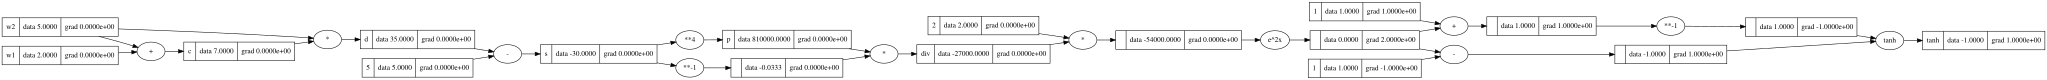

In [158]:
draw_dot(tanh)

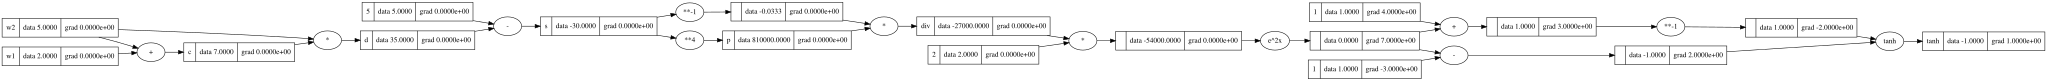

In [166]:
tanh.backward()
draw_dot(tanh)


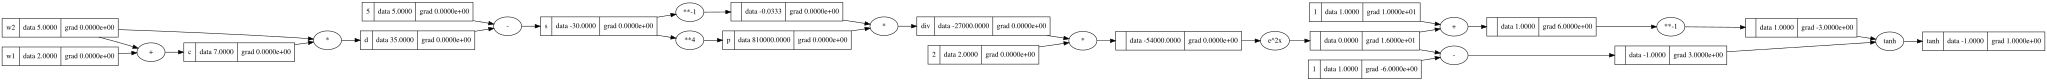

In [167]:
tanh.backward()
draw_dot(tanh)

y data: 0.0997
x1 gradient: 0.1980


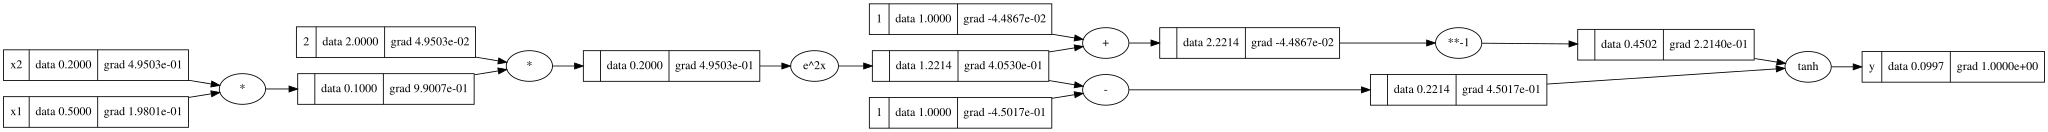

In [160]:
# Testing with smaller values to see non-zero gradients
x1 = nodes(0.5, label='x1')
x2 = nodes(0.2, label='x2')
y = (x1 * x2).tanh(); y._label = 'y'
y.backward()

print(f"y data: {y._data:.4f}")
print(f"x1 gradient: {x1._grad:.4f}")
draw_dot(y)

y data: 0.0997
x1 gradient: 0.1980


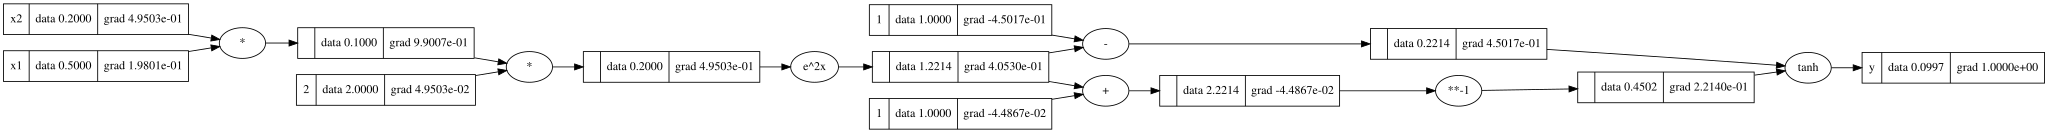

In [168]:
# Testing with smaller values to see non-zero gradients
x1 = nodes(0.5, label='x1')
x2 = nodes(0.2, label='x2')
y = (x1 * x2).tanh(); y._label = 'y'
y.backward()

print(f"y data: {y._data:.4f}")
print(f"x1 gradient: {x1._grad:.4f}")
draw_dot(y)